In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import logging

import numpy as np
import torch

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler()
    ]
)

%reload_ext autoreload
%autoreload 2

from config.constants import Constants
from config.settings import get_settings
from config.train_config import DEFAULT_CONFIG_PATH, load_train_config
from core_data_prep.core_data_prep import DataPreparer
from core_inference.allocators.signal_predictor_allocator import SignalPredictorAllocator
from core_inference.streaming_validation import run_streaming_validation
from data.processed.data_processing_utils import print_data_statistics
from data.processed.dataset_pytorch import DatasetPytorch
from modeling.allocator_evaluation import find_best_allocator_params, test_cum_wealth
from modeling.model_package import build_dataset_reference
from modeling.modeling_utils import print_model_parameters
from modeling.rl.visualization.position_plot import plot_position_heatmap
from modeling.rl.visualization.wealth_plot import plot_cumulative_wealth
from modeling.trainer import Trainer
from observability.wandb_integration import (
    link_model_artifact_to_registry,
    log_epoch_metrics,
    log_test_sequences,
    promote_registry_artifact_to_production,
    publish_training_result,
    start_training_run,
)

settings = get_settings()
config = load_train_config()
wandb_run = start_training_run(config, settings.wandb)
torch.backends.cudnn.benchmark = config.train_config.cudnn_benchmark

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(f"Config:\n {config}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ivan-kurnosau (ivan-kurnosau-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using device: cpu
Config:
 ExperimentConfig(data_config=DataConfig(retriever=<data.raw.retrievers.alpaca_markets_retriever.AlpacaMarketsRetriever object at 0x1493f20f0>, symbol_or_symbols=['AAPL', 'ACWI', 'AMD', 'AMZN', 'APLD', 'ARKK', 'AVGO', 'B', 'BAC', 'BKNG', 'BMY', 'BSX', 'CIFR', 'CSCO', 'DIA', 'DVN', 'EEM', 'EFA', 'EMXC', 'EWT', 'EWY', 'FBTC', 'FCX', 'GDX', 'GLD', 'GOOG', 'GOOGL', 'HOOD', 'IBIT', 'IEMG', 'IGV', 'IJR', 'INTC', 'IONQ', 'IREN', 'IVV', 'IVW', 'IWF', 'IWM', 'IYR', 'KO', 'KRE', 'MARA', 'META', 'MRVL', 'MSFT', 'MSTR', 'MU', 'NEE', 'NFLX', 'NKE', 'NOW', 'NVDA', 'ORCL', 'OXY', 'PLTR', 'PYPL', 'QBTS', 'QLD', 'QQQ', 'QQQM', 'RGTI', 'RIOT', 'RKLB', 'RSP', 'SHEL', 'SLB', 'SLV', 'SMCI', 'SMH', 'SOXX', 'SPXL', 'SPY', 'SPYG', 'STM', 'TFC', 'TQQQ', 'TSLA', 'TSM', 'UBER', 'UPRO', 'USB', 'VNQ', 'VOO', 'VT', 'VTI', 'VTWO', 'VUG', 'WFC', 'WMT', 'WULF', 'XBI', 'XLC', 'XLE', 'XLI', 'XLK', 'XLP', 'XLV', 'XLY', 'XOM'], frequency=<alpaca.data.timeframe.TimeFrame object at 0x14b266270>, st

In [2]:
retriever = config.data_config.retriever
retrieval_result = retriever.bars_with_quotes(
    symbol_or_symbols=config.data_config.symbol_or_symbols,
    start=config.data_config.start,
    end=config.data_config.end,
)

dataset_file_name = retriever.build_file_name(
    config.data_config.symbol_or_symbols,
    config.data_config.start,
    config.data_config.end,
)
dataset_object_key = retriever.build_object_key(
    Constants.Data.Retrieving.Alpaca.BARS_WITH_QUOTES_STORAGE_PREFIX,
    dataset_file_name,
)
dataset_reference = build_dataset_reference(
    retriever.object_store,
    dataset_object_key,
    config.raw_config["data"],
)
dataset_reference

2026-08-16 09:03:01,174 - INFO - Downloading cached Alpaca bars with quotes from cloud storage: bars_with_quotes/1Min_2024-11-01-2026-08-01_AAPL+ACWI+AMD+AMZN+APLD+ARKK+AVGO+B+BAC+BKNG+BMY+BSX+CIFR+CSCO+DIA+DVN+EEM+EFA+EMXC+EWT+EWY+FBTC+FCX_exact-quotes-asof-with-timestamp.pkl
/Users/ivan.kurnosau/Projects/intraday-portfolio-management/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetReference(object_store_uri='s3://intraday-portfolio-management/alpaca/bars_with_quotes/1Min_2024-11-01-2026-08-01_AAPL+ACWI+AMD+AMZN+APLD+ARKK+AVGO+B+BAC+BKNG+BMY+BSX+CIFR+CSCO+DIA+DVN+EEM+EFA+EMXC+EWT+EWY+FBTC+FCX_exact-quotes-asof-with-timestamp.pkl', version_id='4_zac6a8e01c2f5e4509ef40314_f20014162d2e005bc_d20260816_m041822_c005_v0501038_t0024_u01786853902332', size=2227332545, etag='fbf346a903571b8e6595fa4b107ab052-266', fingerprint='91f06eb49c2e097079f33db972f623e61700666f73aaab0db974c28870b3f104', query={'retriever': {'name': 'alpaca_markets', 'params': {'use_quote_estimation': False, 'exact_quote_workers': 300, 'exact_quote_processes': 8, 'quote_requests_per_minute': 9000}}, 'symbols': ['AAPL', 'ACWI', 'AMD', 'AMZN', 'APLD', 'ARKK', 'AVGO', 'B', 'BAC', 'BKNG', 'BMY', 'BSX', 'CIFR', 'CSCO', 'DIA', 'DVN', 'EEM', 'EFA', 'EMXC', 'EWT', 'EWY', 'FBTC', 'FCX', 'GDX', 'GLD', 'GOOG', 'GOOGL', 'HOOD', 'IBIT', 'IEMG', 'IGV', 'IJR', 'INTC', 'IONQ', 'IREN', 'IVV', 'IVW', 'IWF', 'IWM'

In [ ]:
data_preparer = DataPreparer(
    normalizer=config.data_config.normalizer,
    missing_values_handler=config.data_config.missing_values_handler_polars,
    in_seq_len=config.data_config.in_seq_len,
    frequency=str(config.data_config.frequency),
    validator=config.data_config.validator
)

(X_train, y_train, statistics_train), (X_val, y_val, statistics_val), (X_test, y_test, statistics_test) = \
    data_preparer.get_experiment_data(
        data=retrieval_result,
        start_date=config.data_config.start,
        end_date=config.data_config.end,
        features=config.data_config.features_polars,
        statistics=config.data_config.statistics,
        target=config.data_config.target,
        train_set_last_date=config.data_config.train_set_last_date,
        val_set_last_date=config.data_config.val_set_last_date,
        backend='loky'
    )

X_train.shape, y_train.shape, statistics_train['next_return'].shape, \
    X_val.shape, y_val.shape, statistics_val['next_return'].shape, \
    X_test.shape, y_test.shape, statistics_test['next_return'].shape

2026-08-14 17:18:01,803 - INFO - Skipping day 2024-11-02 00:00:00-04:00 because it has less than 100 assets
2026-08-14 17:18:02,516 - INFO - Skipping day 2024-11-05 00:00:00-04:00 because it has less than 100 assets
2026-08-14 17:18:03,273 - INFO - Skipping day 2024-11-06 00:00:00-04:00 because it has less than 100 assets
2026-08-14 17:23:26,031 - INFO - Found 433 daily slices
2026-08-14 17:23:26,075 - INFO - Trained per-asset targets
/Users/ivan.kurnosau/Projects/intraday-portfolio-management/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
next_return_train, spread_train, volatility_train, \
    next_return_val, spread_val, volatility_val, \
    next_return_test, spread_test, volatility_test = \
        statistics_train['next_return'], statistics_train['spread'], statistics_train['volatility'], \
        statistics_val['next_return'], statistics_val['spread'], statistics_val['volatility'], \
        statistics_test['next_return'], statistics_test['spread'], statistics_test['volatility']

print_data_statistics(statistics_train, statistics_val, statistics_test)

Test mean volatility/spread ratio: 5.480728
Train means: |next return| = 0.0003484321 spread = 8.812185e-05 volatility = 0.0004652582
Validation means: |next return| = 0.00035883658 spread = 8.619285e-05 volatility = 0.00047049086
Test means: |next return| = 0.00035937608 spread = 8.562335e-05 volatility = 0.0004793179


In [ ]:
model = config.model_config.model
print(model)
print_model_parameters(model)

TemporalSpatial(
  (asset_embed): Embedding(2, 16)
  (asset_proj): Linear(in_features=16, out_features=256, bias=False)
  (lstm): LSTM(16, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (spatial_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Module                                   Params
------------------------------------------------------------
[ROOT]                                   812833
asset_embed                              32
asset_proj                               4096
lstm                                     544768
spatial_attn                             263168
spatial_attn.out_proj                    65792
fc                                       257
norm                                     

In [6]:
train_loader = DatasetPytorch(X_train, y_train, learning_task='regression').as_dataloader(
    batch_size=config.train_config.batch_size,
    shuffle=config.train_config.shuffle,
    num_workers=config.train_config.num_workers,
    prefetch_factor=config.train_config.prefetch_factor,
    pin_memory=config.train_config.pin_memory,
    persistent_workers=config.train_config.persistent_workers,
    drop_last=config.train_config.drop_last
)
val_loader = DatasetPytorch(X_val, y_val, learning_task='regression').as_dataloader(
    batch_size=config.train_config.batch_size,
    shuffle=False,
    num_workers=config.train_config.num_workers,
    prefetch_factor=config.train_config.prefetch_factor,
    pin_memory=config.train_config.pin_memory,
    persistent_workers=config.train_config.persistent_workers,
    drop_last=config.train_config.drop_last
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=config.train_config.loss_fn,
    optimizer=config.train_config.optimizer,
    scheduler=config.train_config.scheduler,
    num_epochs=config.train_config.num_epochs,
    early_stopping_patience=config.train_config.early_stopping_patience,
    device=config.train_config.device,
    metrics=config.train_config.metrics,
    save_path=config.train_config.save_path,
    epoch_callback=lambda epoch, metrics: log_epoch_metrics(
        wandb_run,
        epoch,
        metrics,
    ),
)

model, history = trainer.train()

2026-08-12 12:47:06,738 - INFO - Epoch 1/20
Training:   0%|          | 0/15 [00:00<?, ?it/s]/Users/ivan.kurnosau/Projects/intraday-portfolio-management/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
2026-08-12 12:47:11,902 - INFO - Train Loss: 0.4353        
2026-08-12 12:47:11,903 - INFO - Train Rmse: 0.6546
2026-08-12 12:47:11,903 - INFO - Val   Loss: 0.2594
2026-08-12 12:47:11,903 - INFO - Val   Rmse: 0.5092
2026-08-12 12:47:11,903 - INFO - New best model found! Updating best state dict.
2026-08-12 12:47:11,904 - INFO - 
2026-08-12 12:47:11,904 - INFO - Epoch 2/20
2026-08-12 12:47:15,482 - INFO - Train Loss: 0.3058        
2026-08-12 12:47:15,482 - INFO - Train Rmse: 0.5510
2026-08-12 12:47:15,482 - INFO - Val   Loss: 0.2435
2026-08-12 12:47:15,482 - INFO - Val   Rmse: 0.4934
2026-08-12 12:47:15,482 - INFO - New best 

In [7]:
best_select_from_n_best, best_confidence_threshold = find_best_allocator_params(
    signal_predictor=model,
    loader=val_loader,
    next_returns=next_return_val,
    spreads=spread_val,
    volatilities=volatility_val,
    trade_asset_count=config.rl_config.trade_asset_count,
    fee=config.rl_config.fee,
    spread_multiplier=config.rl_config.spread_multiplier,
    device=device,
    allow_short_positions=config.rl_config.allow_short_positions,
    n_runs_per_param=20,
)
allocator_params = {
    "trade_asset_count": config.rl_config.trade_asset_count,
    "select_from_n_best": best_select_from_n_best,
    "confidence_threshold": best_confidence_threshold,
}
allocator_params["select_from_n_best"], allocator_params["confidence_threshold"]

2026-08-12 12:48:19,493 - INFO - Running with select_from_n_best: 2
2026-08-12 12:48:20,855 - INFO - Obtained cum wealth: -0.05743378400802612
2026-08-12 12:48:20,855 - INFO - New best select_from_n_best: 2, cum_wealth: -0.05743378400802612
2026-08-12 12:48:20,855 - INFO - Best select_from_n_best: 2

2026-08-12 12:48:20,856 - INFO - Running with select_from_n_best: 2 and confidence threshold: 0.004289478063583374
2026-08-12 12:48:22,367 - INFO - Obtained cum wealth: -0.050746142864227295
2026-08-12 12:48:22,367 - INFO - New best confidence threshold: 0.004289478063583374, cum_wealth: -0.050746142864227295
2026-08-12 12:48:22,368 - INFO - Running with select_from_n_best: 2 and confidence threshold: 0.0048870183919605455
2026-08-12 12:48:23,784 - INFO - Obtained cum wealth: -0.05619996786117554
2026-08-12 12:48:23,784 - INFO - Running with select_from_n_best: 2 and confidence threshold: 0.005484558720337718
2026-08-12 12:48:25,217 - INFO - Obtained cum wealth: -0.0608903169631958
2026-08

(2, 0.014447663645995295)

In [ ]:
use_dummy_allocator = False

if use_dummy_allocator:
    from core_inference.allocators.deterministic_one_stock_allocator import (
        DeterministicOneStockAllocator,
    )

    allocator = DeterministicOneStockAllocator(
        n_assets=len(config.data_config.symbol_or_symbols),
    ).to(device)
    allocator.reset_counter()
else:
    allocator = SignalPredictorAllocator(
        signal_predictor=model,
        trade_asset_count=allocator_params["trade_asset_count"],
        select_from_n_best=allocator_params["select_from_n_best"],
        confidence_threshold=allocator_params["confidence_threshold"],
        allow_short_positions=config.rl_config.allow_short_positions,
    ).to(device)

test_loader = DatasetPytorch(X_test, y_test, learning_task='regression').as_dataloader(
    batch_size=config.train_config.batch_size,
    shuffle=False,
    num_workers=config.train_config.num_workers,
    prefetch_factor=config.train_config.prefetch_factor,
    pin_memory=config.train_config.pin_memory,
    persistent_workers=config.train_config.persistent_workers,
    drop_last=False
)

cum_wealth, realized_returns, allocations, confidences = test_cum_wealth(
    allocator,
    test_loader,
    next_return_test,
    spread_test,
    volatility_test,
    fee=config.rl_config.fee,
    spread_multiplier=config.rl_config.spread_multiplier,
    device=device,
)

log_test_sequences(
    wandb_run,
    realized_returns=realized_returns,
    allocations=allocations,
    asset_names=sorted(retrieval_result),
    confidences=confidences,
)
cum_wealth

-0.023019015789031982

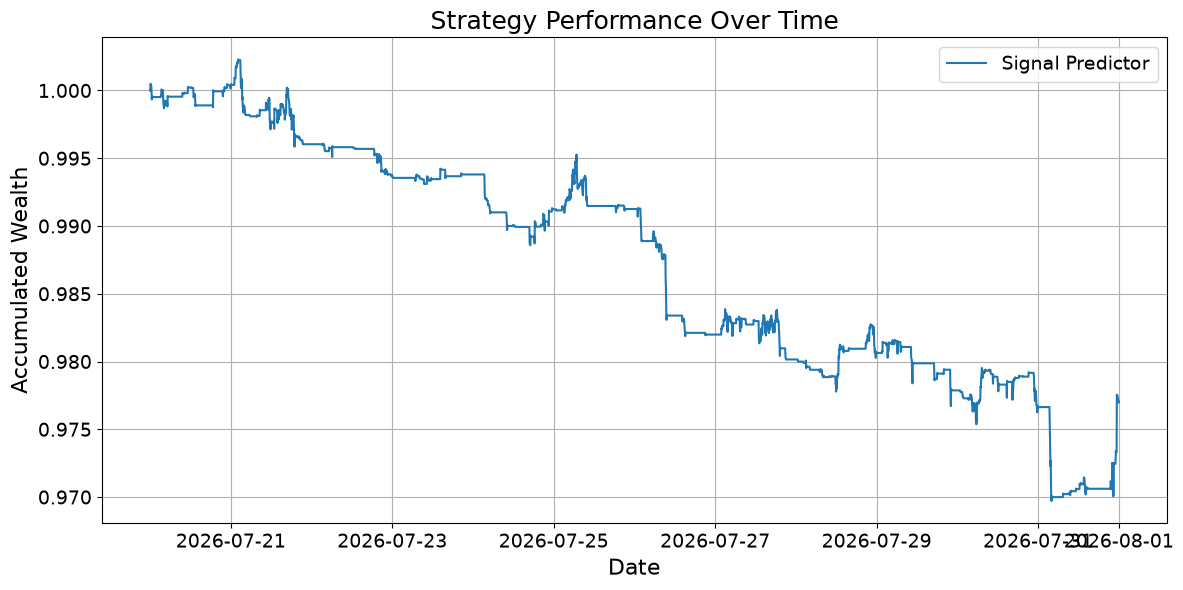

In [9]:
returns_dict = plot_cumulative_wealth(
    returns_dict={
        'Signal Predictor': list(realized_returns) 
    }, 
    start_time=config.data_config.val_set_last_date, 
    end_time=config.data_config.end,
    ours_to_include=[],
    baseline_to_include=[],
    year_start=9
)

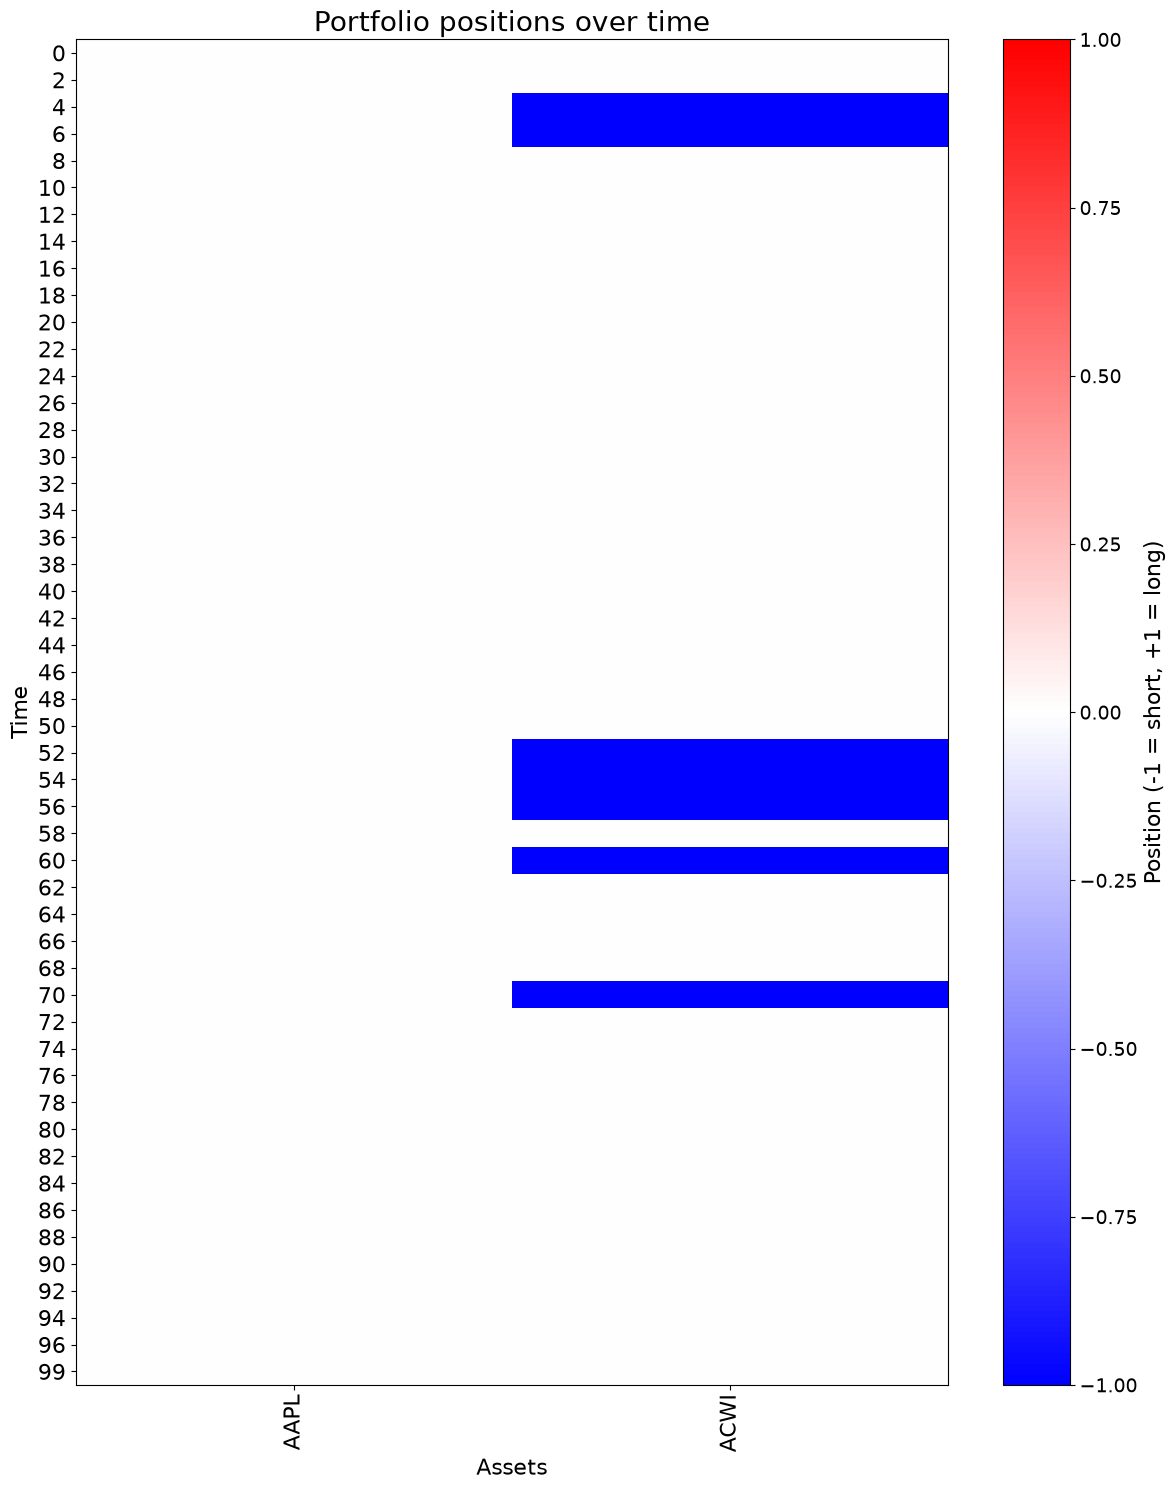

In [10]:
plot_position_heatmap(allocations[:100], asset_names=sorted(list(retrieval_result.keys())))

In [ ]:
daily_slices = data_preparer._get_daily_slices(
    retrieval_result,
    start_date=config.data_config.val_set_last_date,
    end_date=config.data_config.end,
    slice_length=Constants.Data.TRADING_DAY_LENGTH_MINUTES + config.data_config.in_seq_len + config.data_config.normalizer.get_window() + 30,
    verbose=True
)

# assert all the slices have the same length
assert len(set([len(cur_day_asset_slice) for cur_day_slices in daily_slices for cur_day_asset_slice in cur_day_slices.values()])) == 1

len(daily_slices), len(daily_slices[0]), len(daily_slices[0]['AAPL'])

2026-08-12 12:48:52,465 - INFO - Last timestamp counts across all slices and stocks:
2026-08-12 12:48:52,465 - INFO -   2026-07-20 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,465 - INFO -   2026-07-21 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,465 - INFO -   2026-07-22 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,466 - INFO -   2026-07-23 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,466 - INFO -   2026-07-24 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,466 - INFO -   2026-07-27 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,466 - INFO -   2026-07-28 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,466 - INFO -   2026-07-29 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,466 - INFO -   2026-07-30 16:00:00-04:00: 2 occurrences
2026-08-12 12:48:52,467 - INFO -   2026-07-31 16:00:00-04:00: 2 occurrences


(10, 2, 541)

In [ ]:
cur_cash = run_streaming_validation(
    config=config,
    data_preparer=data_preparer,
    allocator=allocator,
    daily_slices=daily_slices,
    x_test=X_test,
    allocations=allocations,
    realized_returns=realized_returns,
    next_returns=next_return_test,
    validate_inputs=True,
    validate_returns=True,
    initial_cash=1e10,
    order_size_notional=1e9,
    reset_allocator=use_dummy_allocator,
    n_days=1,
)

2026-08-12 12:48:52,563 - WARNING - Input mismatch on day 0 at 2026-07-20 09:30:00-04:00: max_abs_diff=0.027636241167783737, median_abs_diff=0.0, mean_abs_diff=0.0007340877200476825
2026-08-12 12:48:52,566 - WARNING - seq positions mismatched: 51/60
    seq_i  allclose  max_abs_diff  median_abs_diff  mean_abs_diff
0       0     False      0.027636              0.0       0.000864
1       2     False      0.027636              0.0       0.000864
2       3     False      0.027636              0.0       0.000864
3       4     False      0.027636              0.0       0.000864
4       5     False      0.027636              0.0       0.000864
5       6     False      0.027636              0.0       0.000864
6       7     False      0.027636              0.0       0.000864
7       8     False      0.027636              0.0       0.000864
8      10     False      0.027636              0.0       0.000864
9      11     False      0.027636              0.0       0.000864
10     12     False     

Validating streaming inputs against offline X_test
Validating streaming allocations/returns against offline test_cum_wealth outputs


2026-08-12 12:48:52,703 - INFO - Running portfolio allocator...
2026-08-12 12:48:52,706 - INFO - New allocation predicted: {'AAPL': 0.9999993}
2026-08-12 12:48:52,707 - INFO - Enter orders: {'AAPL': 3016134.0}
2026-08-12 12:48:52,707 - INFO - Exit orders: {}
2026-08-12 12:48:52,707 - INFO - Starting order execution...
2026-08-12 12:48:52,708 - INFO - Order execution completed!
2026-08-12 12:48:52,708 - INFO - Brokerage states: {'backtest': BrokerageState(equity=9999920826.4825, cash_balance=8999921598.7825, shares_hold={'AAPL': 3016134.0})}
2026-08-12 12:48:52,709 - INFO - Day 0 update 1 at 2026-07-20 09:31:00-04:00 ended with equity 9999920826.4825
2026-08-12 12:48:52,750 - WARNING - Input mismatch on day 0 at 2026-07-20 09:32:00-04:00: max_abs_diff=0.027636241167783737, median_abs_diff=0.0, mean_abs_diff=0.000705299957189709
2026-08-12 12:48:52,752 - WARNING - seq positions mismatched: 49/60
    seq_i  allclose  max_abs_diff  median_abs_diff  mean_abs_diff
0       1     False      0.

In [13]:
published_model = publish_training_result(
    run=wandb_run,
    model=model,
    train_config_path=DEFAULT_CONFIG_PATH,
    allocator_params=allocator_params,
    dataset_reference=dataset_reference,
    final_metrics={
        "accumulated_wealth": cum_wealth,
        "best_epoch": int(np.argmin(history["val_loss"]) + 1),
        "best_validation_loss": float(min(history["val_loss"])),
        "streaming_final_cash": cur_cash,
    },
    settings=settings,
)
published_model

2026-08-12 12:50:05,605 - INFO - Found credentials in environment variables.
wandb: Generating checksum for up to 10000000 objects in "intraday-portfolio-management/models/xqz2ac51"... Done. 0.7s
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test/allocation/AAPL,▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁█▁▁▁█▁▁█
test/allocation/ACWI,▁▄█▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄█▄▄▄▄▁▄▄▁▄▄▄▄▄▄▄▄▄▄▄▄
test/confidence,▄▃█▂▂▅▃▂▂▂▄▁▂▇▃▃▄▅▂▅▃▄▃▃▁▄▄▃█▃▇▄▃▃▅▃▂▄▆▅
test/cumulative_wealth,▇███▇▇▇▆▆▆▅▅▅▅▅▅▆▆▅▄▄▃▃▃▂▂▃▃▃▂▃▂▂▂▂▁▂▂▂▁
test/realized_return,▇▇▇▇▇▇▇▁▇▇▇▇▆▇▇▇▇▆▇▇▇▇▆▆▇▇▇▇▇▆▆▇▇▇▆▇█▇▇▇
test/step,▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/loss,█▃▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
train/rmse,█▄▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
validation/loss,▇▃█▆▃▃█▅▁▁▁▁▂▁▃▁▁▁▁▁
+1,...


PublishedWandbModel(source_artifact_name='ivan-kurnosau-personal/intraday-portfolio-management/portfolio-allocation-model:v1', object_store_uri='s3://intraday-portfolio-management/models/xqz2ac51', package_metadata={'model_package_format_version': 1, 'checkpoint_format_version': 1, 'model_format': 'pytorch_state_dict', 'wandb_run_id': 'xqz2ac51', 'object_store_uri': 's3://intraday-portfolio-management/models/xqz2ac51', 'created_at': '2026-08-12T10:50:02.261533+00:00', 'git_commit': 'ebbfd8c057e6229f7b1239810b615cd24451626e', 'pytorch_version': '2.13.0', 'dataset': {'object_store_uri': 's3://intraday-portfolio-management/alpaca/bars_with_quotes/1Min_2026-07-01-2026-08-01_AAPL+ACWI.pkl', 'version_id': '4_zac6a8e01c2f5e4509ef40314_f109c95b1440310fa_d20260812_m100143_c005_v0501007_t0038_u01786528903140', 'size': 2180324, 'etag': 'f046464ceeedca88540909916d8a62bc', 'fingerprint': 'ea5abe496a4df29ad0525c70c0648b4e0d6f20a11742797e8b2d3c4076e03e82', 'query': {'retriever': {'name': 'alpaca_mark

In [ ]:
linked_artifact_name = link_model_artifact_to_registry(
    published_model.source_artifact_name,
    settings.wandb,
)
linked_artifact_name

'ivan-kurnosau-personal-org/wandb-registry-Models/portfolio-allocation-model:v1'

In [ ]:
promote_by_default = False

if promote_by_default:
    production_artifact_path = promote_registry_artifact_to_production(
        linked_artifact_name,
        settings.wandb,
    )
    production_artifact_path

'wandb-registry-Models/portfolio-allocation-model:production'